In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")
sns.set_palette("Set2")

# Data load

In [20]:
df1 = pd.read_json("./analysis_data/phase_1.json", lines=True)
df2 = pd.read_json("./analysis_data/phase_2.json", lines=True)
df3 = pd.read_json("./analysis_data/phase_3.json", lines=True)
df4 = pd.read_json("./analysis_data/phase_4.json", lines=True)
df_per_class = pd.read_json("./analysis_data/per_class_metrics.json", lines=True)

In [21]:
df1.columns

Index(['run_id', 'phase', 'metric_phase', 'epoch', 'step', 'macro_f1',
       'command_macro_f1', 'core_command_macro_f1', 'unknown_f1', 'silence_f1',
       'macro_f1_nc', 'unknown_to_command_leakage',
       'silence_false_trigger_rate', 'trial_seed', 'feature_pipeline',
       'model_family'],
      dtype='object')

In [22]:
df2.columns

Index(['run_id', 'phase', 'metric_phase', 'epoch', 'step', 'macro_f1',
       'command_macro_f1', 'core_command_macro_f1', 'unknown_f1', 'silence_f1',
       'macro_f1_nc', 'unknown_to_command_leakage',
       'silence_false_trigger_rate', 'trial_seed', 'feature_pipeline',
       'model_family', 'weight_decay', 'scheduler'],
      dtype='object')

In [23]:
df3.columns

Index(['run_id', 'phase', 'metric_phase', 'epoch', 'step', 'macro_f1',
       'command_macro_f1', 'core_command_macro_f1', 'unknown_f1', 'silence_f1',
       'macro_f1_nc', 'unknown_to_command_leakage',
       'silence_false_trigger_rate', 'trial_seed', 'model_family', 'ast_head',
       'ast_embedding', 'dropout', 'kernel_size', 'sd', 'head_l2'],
      dtype='object')

In [24]:
df4.columns

Index(['run_id', 'phase', 'metric_phase', 'epoch', 'step', 'macro_f1',
       'command_macro_f1', 'core_command_macro_f1', 'unknown_f1', 'silence_f1',
       'macro_f1_nc', 'unknown_to_command_leakage',
       'silence_false_trigger_rate', 'trial_seed', 'eval_strat',
       'model_family', 'ast_head', 'ast_embedding', 'dropout', 'kernel_size',
       'sd', 'head_l2'],
      dtype='object')

In [25]:
df_per_class.columns

Index(['run_id', 'class_name', 'precision', 'recall', 'f1', 'phase'], dtype='object')

# Phase 1

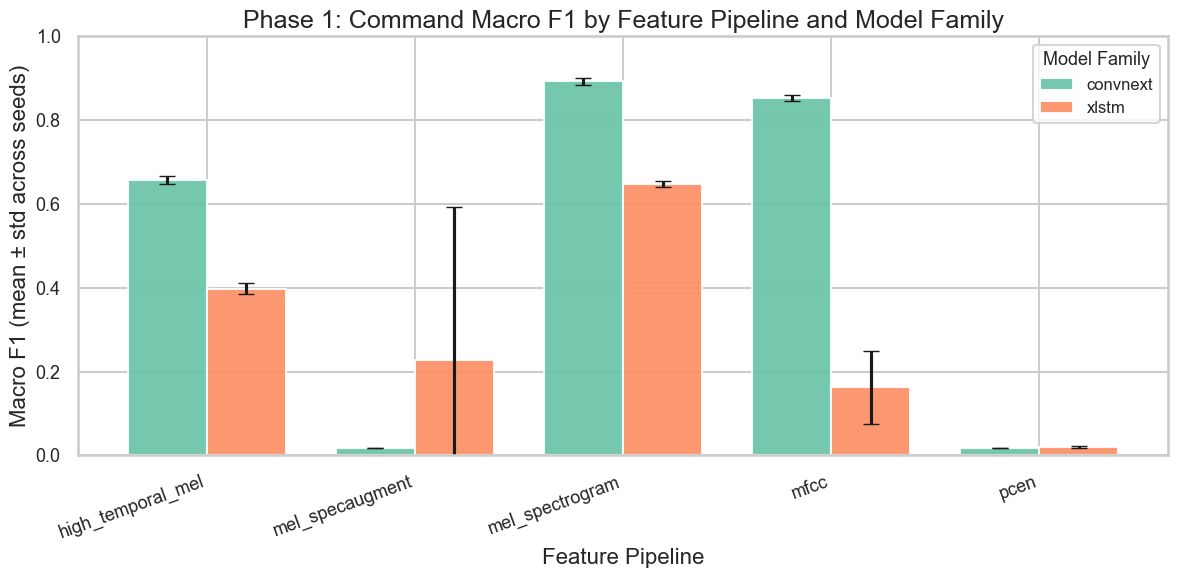

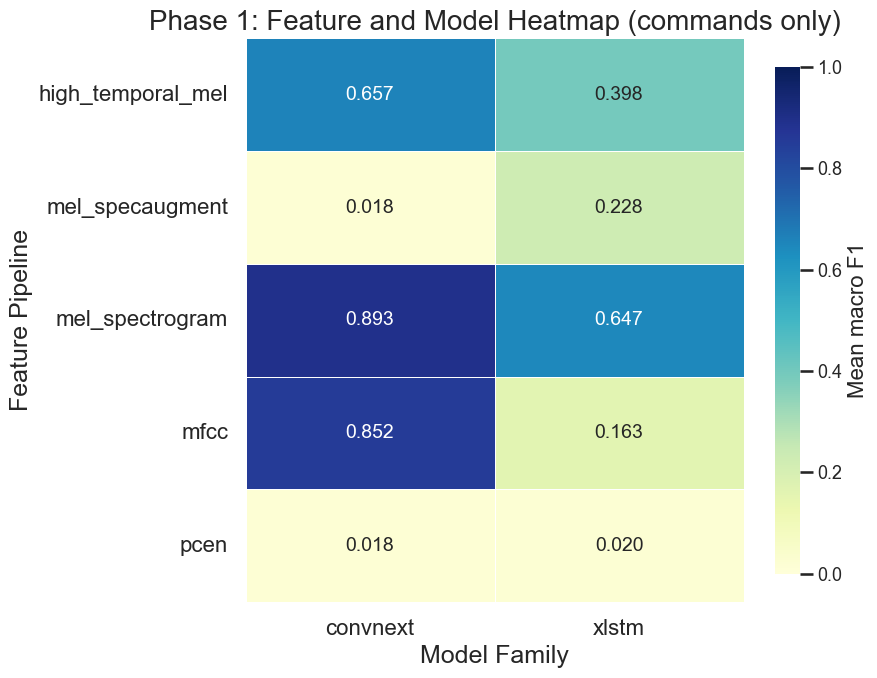

In [26]:
phase1 = df1.copy()

feature_order = [
    "high_temporal_mel",
    "mel_specaugment",
    "mel_spectrogram",
    "mfcc",
    "pcen",
]
model_order = ["convnext", "xlstm"]

phase1["feature_pipeline"] = pd.Categorical(
    phase1["feature_pipeline"], categories=feature_order, ordered=True
)
phase1["model_family"] = pd.Categorical(
    phase1["model_family"], categories=model_order, ordered=True
)

agg = (
    phase1.groupby(["feature_pipeline", "model_family"], observed=True)
    .agg(
        mean_macro_f1=("macro_f1", "mean"),
        std_macro_f1=("macro_f1", "std"),
        mean_command_macro_f1=("command_macro_f1", "mean"),
        std_command_macro_f1=("command_macro_f1", "std"),
        n_runs=("run_id", "count"),
    )
    .reset_index()
)

agg["std_macro_f1"] = agg["std_macro_f1"].fillna(0.0)

# -------- Grouped bar with error bars --------
fig, ax = plt.subplots(figsize=(12, 6))

x_features = agg["feature_pipeline"].cat.categories.tolist()
x = np.arange(len(x_features))
bar_width = 0.38

for i, model in enumerate(model_order):
    model_df = agg[agg["model_family"] == model].set_index("feature_pipeline").reindex(x_features)

    ax.bar(
        x + (i - 0.5) * bar_width,
        model_df["mean_command_macro_f1"],
        yerr=model_df["std_command_macro_f1"],
        width=bar_width,
        capsize=6,
        label=model,
        alpha=0.9,
    )

ax.set_title("Phase 1: Command Macro F1 by Feature Pipeline and Model Family")
ax.set_xlabel("Feature Pipeline")
ax.set_ylabel("Macro F1 (mean ± std across seeds)")
ax.set_xticks(x)
ax.set_xticklabels(x_features, rotation=20, ha="right")
ax.set_ylim(0, 1.0)
ax.legend(title="Model Family", loc="upper right")
plt.tight_layout()
plt.show()

# -------- Heatmap --------
heatmap_df = agg.pivot(
    index="feature_pipeline", columns="model_family", values="mean_command_macro_f1"
).reindex(index=feature_order, columns=model_order)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    linewidths=0.6,
    cbar_kws={"label": "Mean macro F1", "shrink": 0.9},
    annot_kws={"size": 14},
    ax=ax,
)
ax.set_title("Phase 1: Feature and Model Heatmap (commands only)", fontsize=20)
ax.set_xlabel("Model Family", fontsize=18)
ax.set_ylabel("Feature Pipeline", fontsize=18)
ax.tick_params(labelsize=16)
plt.tight_layout()
plt.savefig("./plots/phase_1_heatmap.png", dpi=500)
plt.show()

# Phase 2

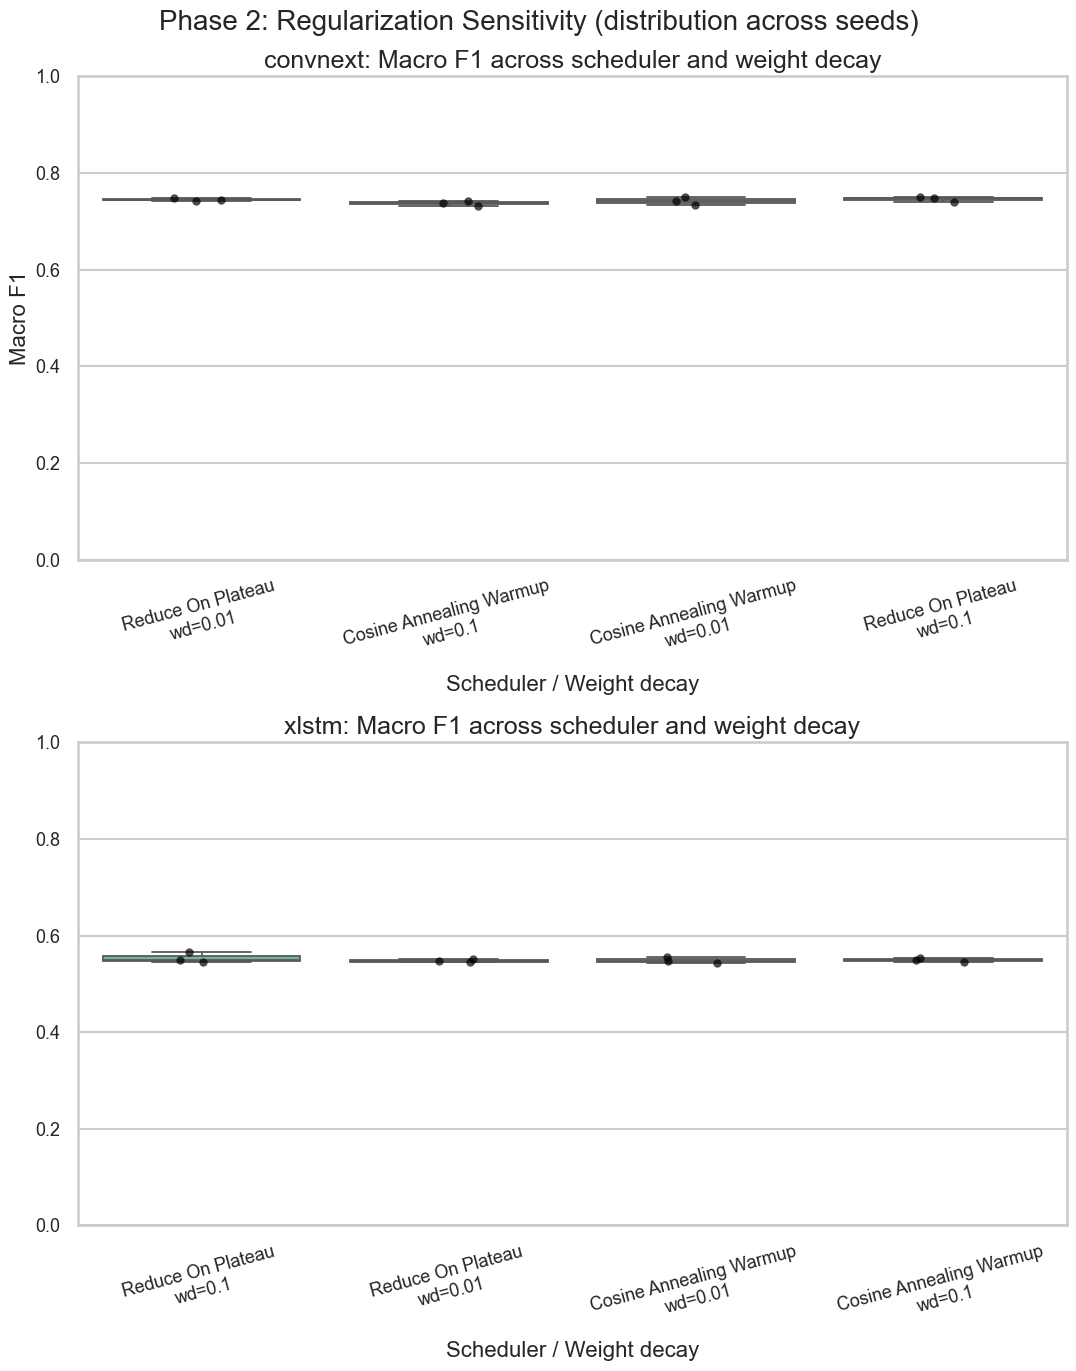

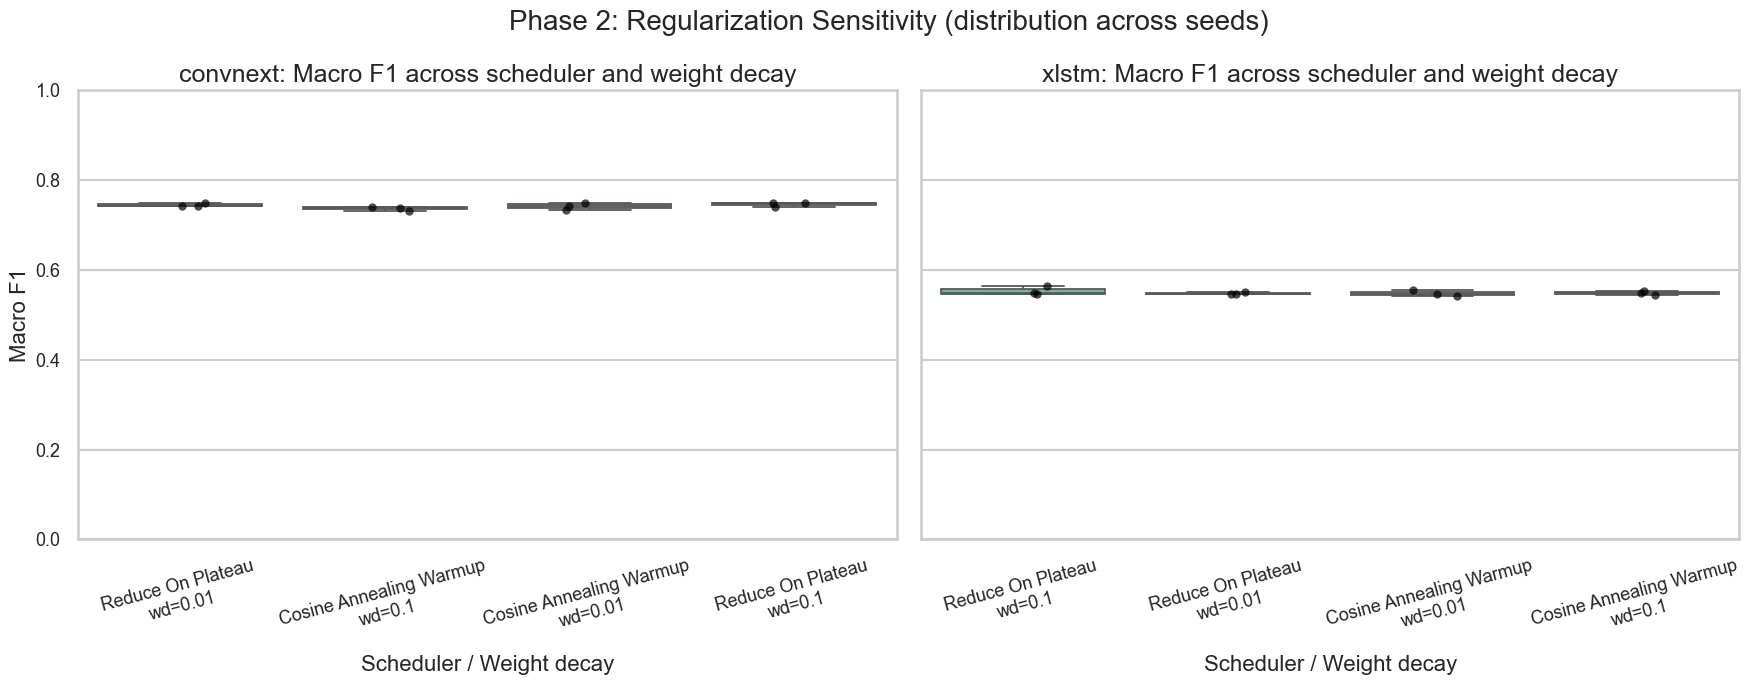

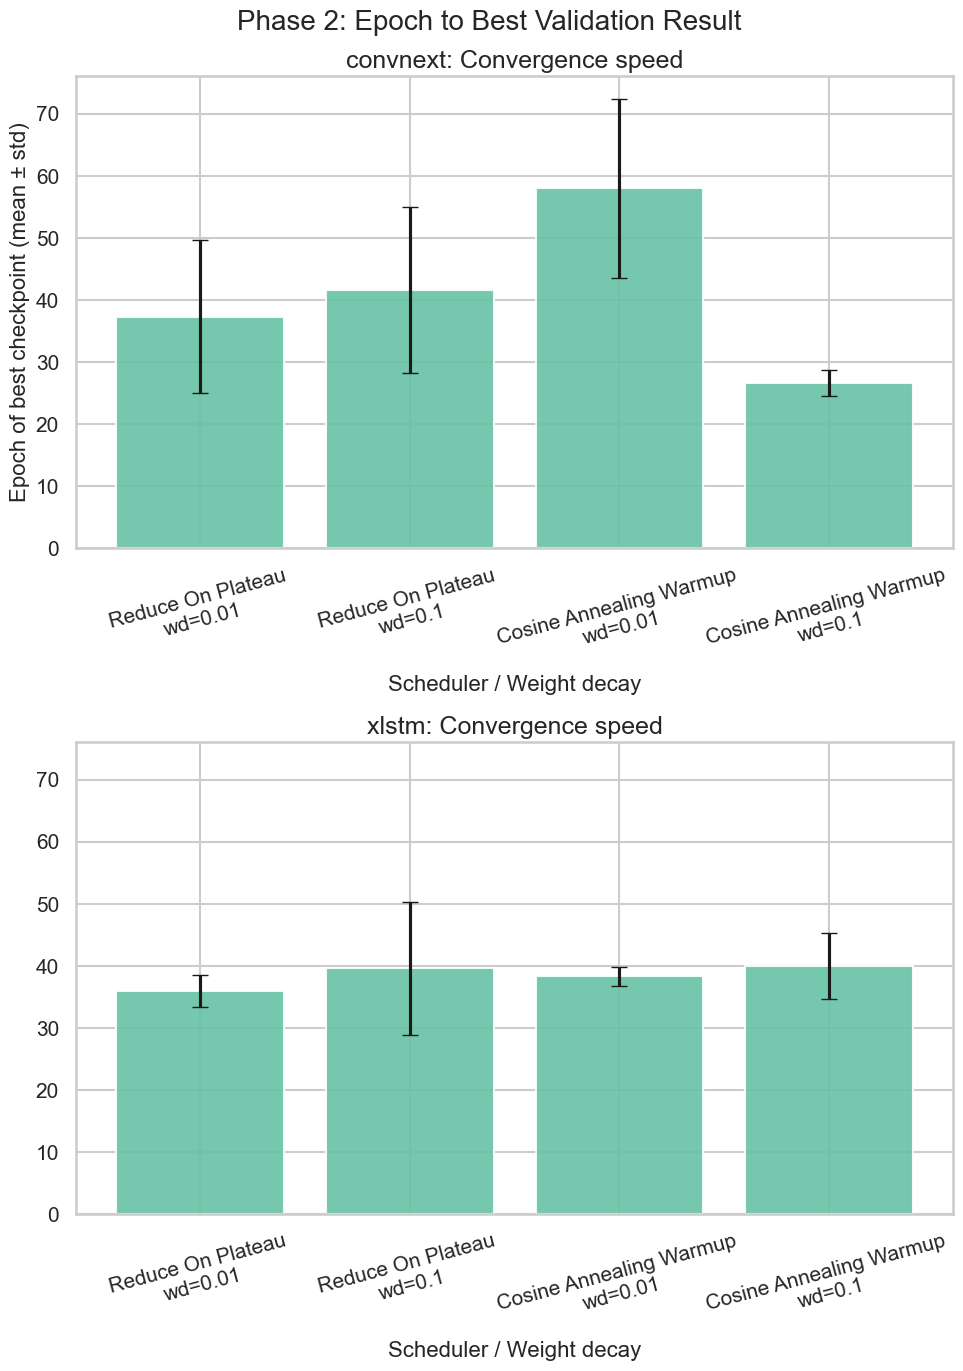

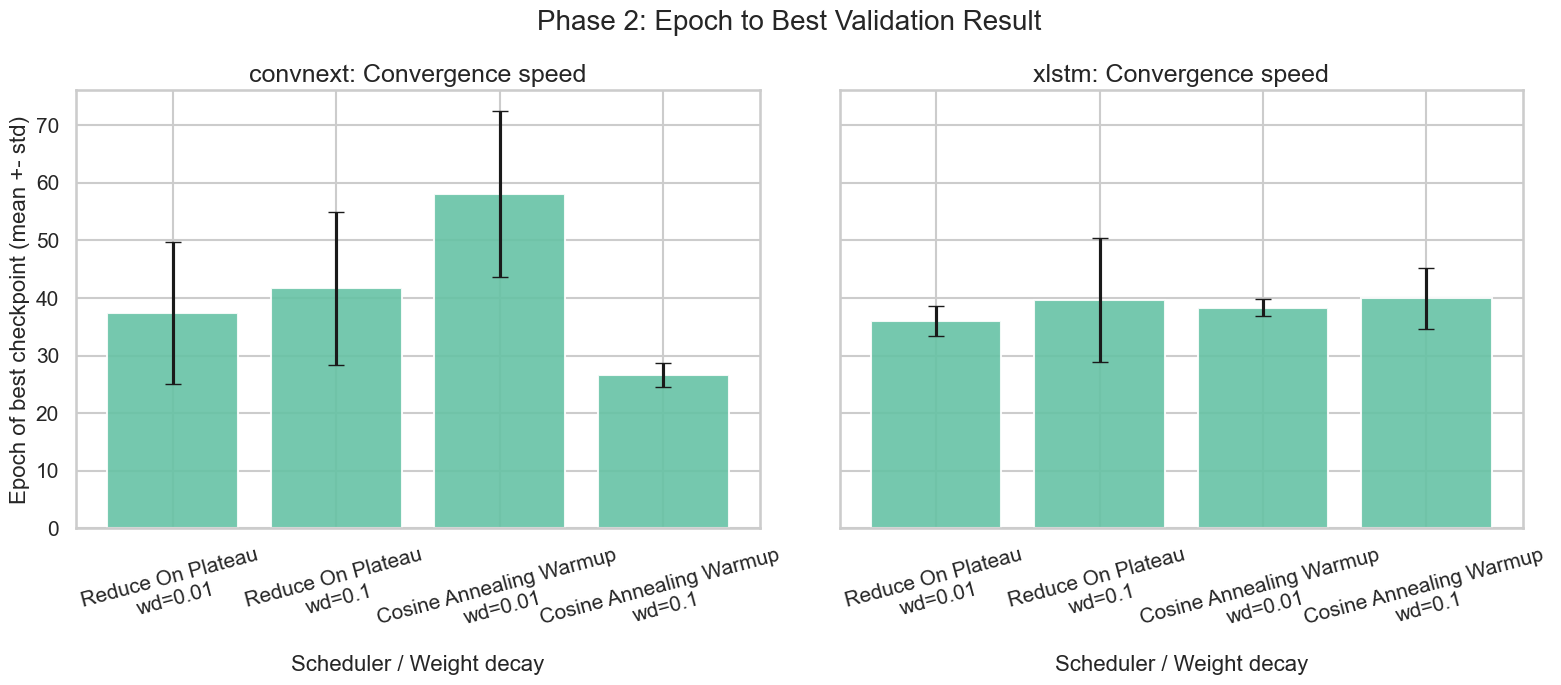

In [27]:
phase2 = df2.copy()

# Consistent ordering for report readability
model_order = ["convnext", "xlstm"]
scheduler_order = ["cosine_annealing_warmup", "reduce_on_plateau"]
wd_order = ["0.01", "0.1"]

phase2["model_family"] = pd.Categorical(
    phase2["model_family"], categories=model_order, ordered=True
)
phase2["scheduler"] = pd.Categorical(phase2["scheduler"], categories=scheduler_order, ordered=True)
phase2["weight_decay"] = phase2["weight_decay"].astype(str)
phase2["weight_decay"] = pd.Categorical(phase2["weight_decay"], categories=wd_order, ordered=True)
phase2["config_label"] = (
    phase2["scheduler"].astype(str).str.replace("_", " ").str.title()
    + "\nwd="
    + phase2["weight_decay"].astype(str)
)

# -------- Sensitivity distribution --------
fig, axes = plt.subplots(2, 1, figsize=(11, 14), sharey=True)

for ax, model in zip(axes, model_order, strict=True):
    plot_df = phase2[phase2["model_family"] == model].copy()

    sns.boxplot(
        data=plot_df,
        x="config_label",
        y="macro_f1",
        dodge=False,
        fliersize=0,
        linewidth=1.3,
        ax=ax,
    )
    sns.stripplot(
        data=plot_df,
        x="config_label",
        y="macro_f1",
        color="black",
        size=6,
        jitter=0.12,
        alpha=0.7,
        ax=ax,
    )

    ax.set_title(f"{model}: Macro F1 across scheduler and weight decay")
    ax.set_xlabel("Scheduler / Weight decay")
    ax.set_ylim(0, 1.0)
    ax.tick_params(axis="x", rotation=15)

    # Keep legend only on first facet
    if ax is axes[0]:
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(
                handles[: len(wd_order)],
                labels[: len(wd_order)],
                title="weight_decay",
                loc="lower right",
            )
    else:
        if ax.get_legend() is not None:
            ax.get_legend().remove()

axes[0].set_ylabel("Macro F1")
axes[1].set_ylabel("")
fig.suptitle(
    "Phase 2: Regularization Sensitivity (distribution across seeds)",
    fontsize=20,
)
plt.tight_layout()
plt.savefig("./plots/phase_2_regularization_sensitivity.png", dpi=500)
plt.show()

# -------- Sensitivity distribution (2-column copy) --------
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

for ax, model in zip(axes, model_order, strict=True):
    plot_df = phase2[phase2["model_family"] == model].copy()

    sns.boxplot(
        data=plot_df,
        x="config_label",
        y="macro_f1",
        dodge=False,
        fliersize=0,
        linewidth=1.3,
        ax=ax,
    )
    sns.stripplot(
        data=plot_df,
        x="config_label",
        y="macro_f1",
        color="black",
        size=6,
        jitter=0.12,
        alpha=0.7,
        ax=ax,
    )

    ax.set_title(f"{model}: Macro F1 across scheduler and weight decay")
    ax.set_xlabel("Scheduler / Weight decay")
    ax.set_ylim(0, 1.0)
    ax.tick_params(axis="x", rotation=15)

axes[0].set_ylabel("Macro F1")
axes[1].set_ylabel("")
fig.suptitle(
    "Phase 2: Regularization Sensitivity (distribution across seeds)",
    fontsize=20,
)
plt.tight_layout()
plt.savefig("./plots/phase_2_regularization_sensitivity_2col.png", dpi=500)
plt.show()

# -------- Plot 2: convergence speed --------
conv = (
    phase2.groupby(["model_family", "scheduler", "weight_decay"], observed=True)
    .agg(
        mean_best_epoch=("epoch", "mean"),
        std_best_epoch=("epoch", "std"),
        runs=("run_id", "count"),
    )
    .reset_index()
)
conv["std_best_epoch"] = conv["std_best_epoch"].fillna(0.0)
conv["config_label"] = (
    conv["scheduler"].astype(str).str.replace("_", " ").str.title()
    + "\nwd="
    + conv["weight_decay"].astype(str)
)

fig, axes = plt.subplots(2, 1, figsize=(10, 14), sharey=True)

for ax, model in zip(axes, model_order, strict=True):
    model_df = conv[conv["model_family"] == model].copy()
    order_labels = [
        "Reduce On Plateau\nwd=0.01",
        "Reduce On Plateau\nwd=0.1",
        "Cosine Annealing Warmup\nwd=0.01",
        "Cosine Annealing Warmup\nwd=0.1",
    ]
    model_df["config_label"] = pd.Categorical(
        model_df["config_label"], categories=order_labels, ordered=True
    )
    model_df = model_df.sort_values("config_label")

    ax.bar(
        x=range(len(model_df)),
        height=model_df["mean_best_epoch"],
        yerr=model_df["std_best_epoch"],
        capsize=6,
        alpha=0.9,
    )
    ax.set_xticks(range(len(model_df)))
    ax.set_xticklabels(model_df["config_label"], rotation=15)
    ax.tick_params(labelsize=15)
    ax.set_title(f"{model}: Convergence speed", fontsize=18)
    ax.set_xlabel("Scheduler / Weight decay", fontsize=16)

axes[0].set_ylabel("Epoch of best checkpoint (mean ± std)", fontsize=16)
axes[1].set_ylabel("")
fig.suptitle("Phase 2: Epoch to Best Validation Result", fontsize=20)
plt.tight_layout()
plt.savefig("./plots/phase_2_convergence_speed.png", dpi=500)
plt.show()

# -------- Convergence speed (2-column copy) --------
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

for ax, model in zip(axes, model_order, strict=True):
    model_df = conv[conv["model_family"] == model].copy()
    order_labels = [
        "Reduce On Plateau\nwd=0.01",
        "Reduce On Plateau\nwd=0.1",
        "Cosine Annealing Warmup\nwd=0.01",
        "Cosine Annealing Warmup\nwd=0.1",
    ]
    model_df["config_label"] = pd.Categorical(
        model_df["config_label"], categories=order_labels, ordered=True
    )
    model_df = model_df.sort_values("config_label")

    ax.bar(
        x=range(len(model_df)),
        height=model_df["mean_best_epoch"],
        yerr=model_df["std_best_epoch"],
        capsize=6,
        alpha=0.9,
    )
    ax.set_xticks(range(len(model_df)))
    ax.set_xticklabels(model_df["config_label"], rotation=15)
    ax.tick_params(labelsize=15)
    ax.set_title(f"{model}: Convergence speed", fontsize=18)
    ax.set_xlabel("Scheduler / Weight decay", fontsize=16)

axes[0].set_ylabel("Epoch of best checkpoint (mean +- std)", fontsize=16)
axes[1].set_ylabel("")
fig.suptitle("Phase 2: Epoch to Best Validation Result", fontsize=20)
plt.tight_layout()
plt.savefig("./plots/phase_2_convergence_speed_2col.png", dpi=500)
plt.show()

# Phase 3

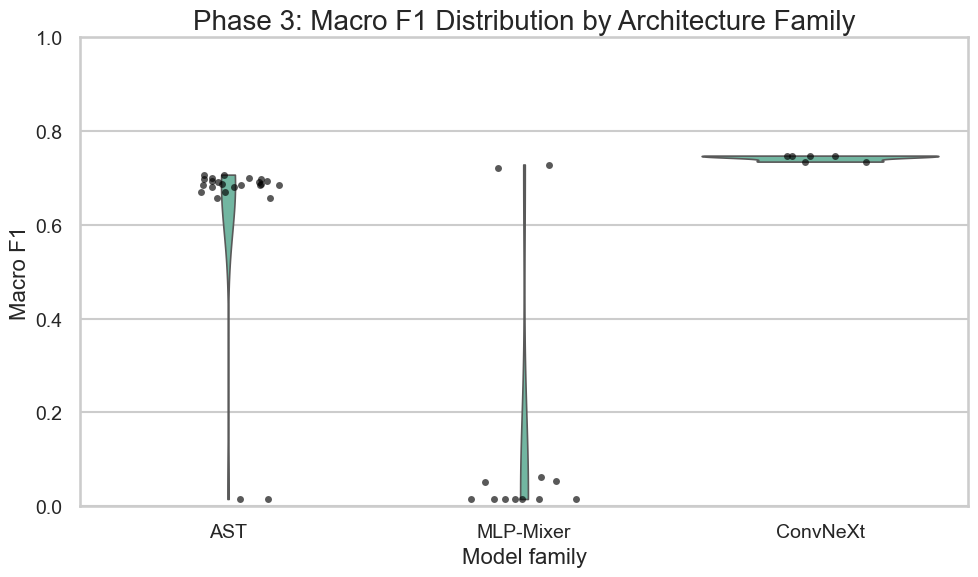

In [28]:
phase3 = df3.copy()

model_order = ["convnext", "ast", "mlp_mixer"]
model_display = {"convnext": "ConvNeXt", "ast": "AST", "mlp_mixer": "MLP-Mixer"}
phase3["model_family"] = pd.Categorical(
    phase3["model_family"], categories=model_order, ordered=True
)
phase3["model_label"] = phase3["model_family"].astype(str).map(model_display)

# -------- Architecture distribution --------
fig, ax = plt.subplots(figsize=(10, 6))

sns.violinplot(
    data=phase3,
    x="model_label",
    y="macro_f1",
    inner=None,
    cut=0,
    linewidth=1.2,
    ax=ax,
)
sns.stripplot(
    data=phase3,
    x="model_label",
    y="macro_f1",
    color="black",
    jitter=0.18,
    size=5,
    alpha=0.65,
    ax=ax,
)

ax.set_title("Phase 3: Macro F1 Distribution by Architecture Family", fontsize=20)
ax.set_xlabel("Model family", fontsize=16)
ax.set_ylabel("Macro F1", fontsize=16)
ax.tick_params(labelsize=14)
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.savefig("./plots/phase_3_architecture_distribution.png", dpi=500)
plt.show()

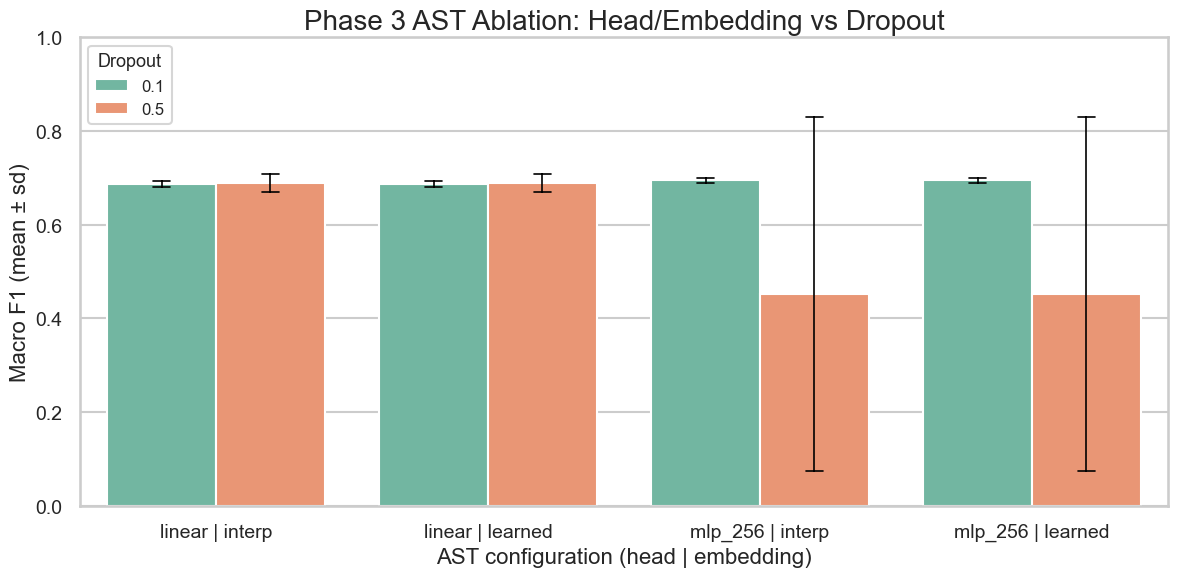

In [29]:
# -------- AST ablation (head x embedding x dropout) --------
ast_df = phase3[phase3["model_family"] == "ast"].copy()
ast_df = ast_df.dropna(subset=["ast_head", "ast_embedding", "dropout"])

ast_df["ast_head"] = ast_df["ast_head"].astype(str)
ast_df["ast_embedding"] = ast_df["ast_embedding"].astype(str)
ast_df["dropout"] = ast_df["dropout"].astype(str)
ast_df["config"] = ast_df["ast_head"] + " | " + ast_df["ast_embedding"]

config_order = sorted(ast_df["config"].unique())
dropout_order = sorted(ast_df["dropout"].unique(), key=lambda x: float(x))

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=ast_df,
    x="config",
    y="macro_f1",
    hue="dropout",
    order=config_order,
    hue_order=dropout_order,
    estimator="mean",
    errorbar="sd",
    capsize=0.12,
    err_kws={"linewidth": 1.2, "color": "black"},
    ax=ax,
)

ax.set_title("Phase 3 AST Ablation: Head/Embedding vs Dropout", fontsize=20)
ax.set_xlabel("AST configuration (head | embedding)", fontsize=16)
ax.set_ylabel("Macro F1 (mean ± sd)", fontsize=16)
ax.set_ylim(0, 1.0)
ax.tick_params(
    axis="x",
    # rotation=20,
    labelsize=14,
)
ax.tick_params(axis="y", labelsize=14)
ax.legend(title="Dropout", loc="upper left")
plt.tight_layout()
# plt.savefig("./plots/phase_3_ast_ablation.png", dpi=500)
plt.show()

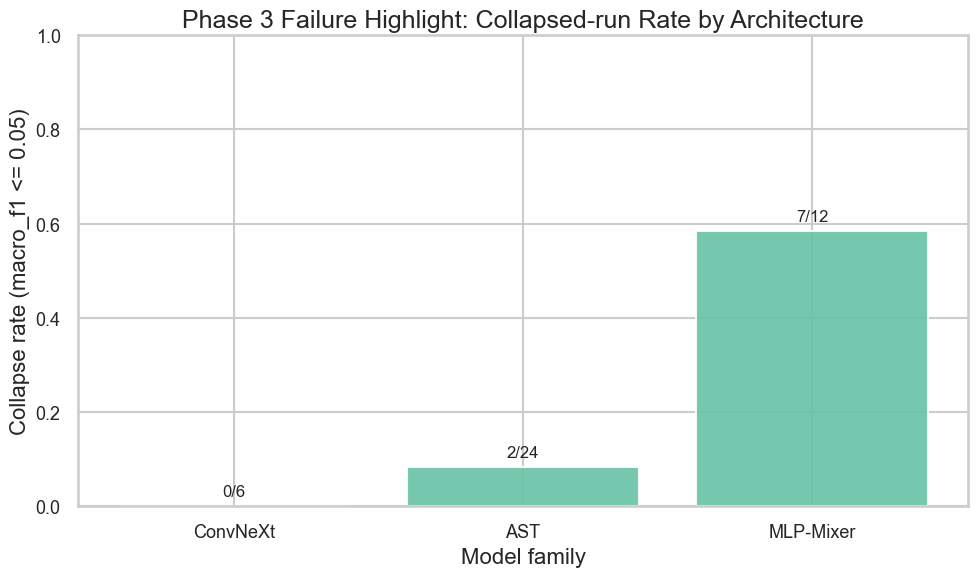

In [30]:
# -------- Plot 3: failure highlight (collapsed runs) --------
# Collapse threshold: near-random multiclass behavior observed in experiments.
collapse_threshold = 0.05

failure = (
    phase3.groupby("model_family", observed=True)
    .agg(
        total_runs=("run_id", "count"),
        collapsed_runs=("macro_f1", lambda s: int((s <= collapse_threshold).sum())),
        median_macro_f1=("macro_f1", "median"),
    )
    .reset_index()
)
failure["collapse_rate"] = failure["collapsed_runs"] / failure["total_runs"]
failure["model_label"] = failure["model_family"].astype(str).map(model_display)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(failure["model_label"], failure["collapse_rate"], alpha=0.9)

for bar, (_, row) in zip(bars, failure.iterrows(), strict=True):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.015,
        f"{row['collapsed_runs']}/{row['total_runs']}",
        ha="center",
        va="bottom",
        fontsize=12,
    )

ax.set_title("Phase 3 Failure Highlight: Collapsed-run Rate by Architecture", fontsize=18)
ax.set_xlabel("Model family", fontsize=16)
ax.set_ylabel(f"Collapse rate (macro_f1 <= {collapse_threshold:.2f})", fontsize=16)
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.savefig("./plots/phase_3_failure_highlight.png", dpi=500)
plt.show()

# Phase 4

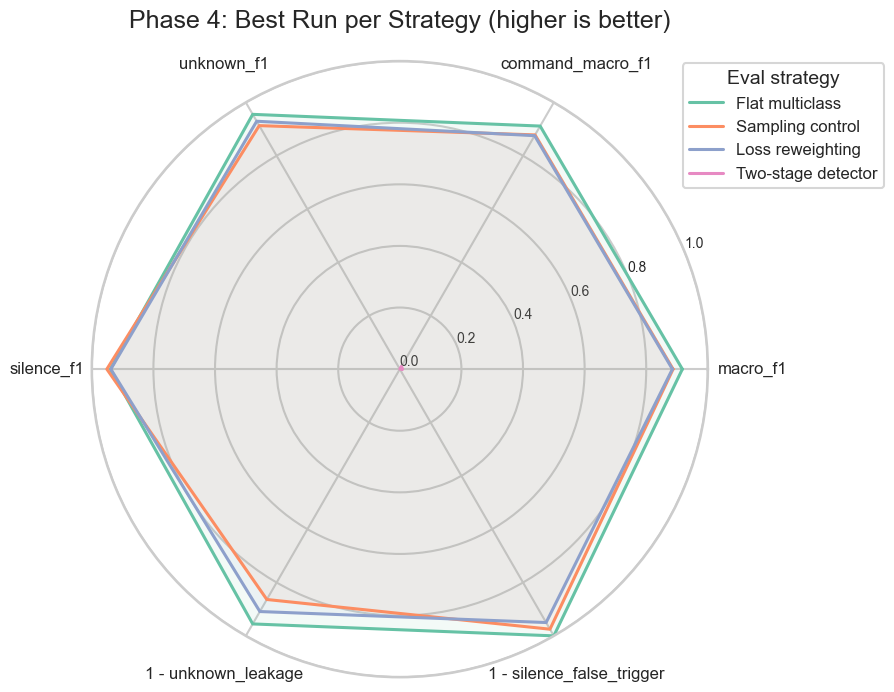

In [ ]:
phase4 = df4.copy()

strategy_order = [
    "flat_multiclass",
    "sampling_control",
    "loss_reweighting",
    "two_stage_detector",
]
model_order = ["convnext", "ast", "mlp_mixer"]

strategy_display = {
    "flat_multiclass": "Flat multiclass",
    "sampling_control": "Sampling control",
    "loss_reweighting": "Loss reweighting",
    "two_stage_detector": "Two-stage detector",
}
model_display = {"convnext": "ConvNeXt", "ast": "AST", "mlp_mixer": "MLP-Mixer"}

phase4["eval_strat"] = pd.Categorical(phase4["eval_strat"], categories=strategy_order, ordered=True)
phase4["model_family"] = pd.Categorical(
    phase4["model_family"], categories=model_order, ordered=True
)
phase4["eval_label"] = phase4["eval_strat"].astype(str).map(strategy_display)
phase4["model_label"] = phase4["model_family"].astype(str).map(model_display)

# -------- Plot 1: radar chart (best run per strategy) --------
# Use transformed leakage axis (1 - leakage) so larger is always better.
radar_metrics = [
    "macro_f1",
    "command_macro_f1",
    "unknown_f1",
    "silence_f1",
    "unknown_to_command_leakage",
    "silence_false_trigger_rate",
]

best_idx = phase4.groupby("eval_strat", observed=True)["macro_f1"].idxmax()
best_per_strategy = phase4.loc[best_idx, ["eval_strat", *radar_metrics]].copy()

best_per_strategy["one_minus_leakage"] = 1.0 - best_per_strategy["unknown_to_command_leakage"]
best_per_strategy["one_minus_false_trigger"] = 1.0 - best_per_strategy["silence_false_trigger_rate"]

radar_axes = [
    "macro_f1",
    "command_macro_f1",
    "unknown_f1",
    "silence_f1",
    "one_minus_leakage",
    "one_minus_false_trigger",
]
radar_labels = [
    "macro_f1",
    "command_macro_f1",
    "unknown_f1",
    "silence_f1",
    "1 - unknown_leakage",
    "1 - silence_false_trigger",
]

angles = np.linspace(0, 2 * np.pi, len(radar_axes), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"polar": True})

for _, row in best_per_strategy.sort_values("eval_strat").iterrows():
    values = row[radar_axes].to_numpy(dtype=float).tolist()
    values += values[:1]
    label = strategy_display.get(str(row["eval_strat"]), str(row["eval_strat"]))
    ax.plot(angles, values, linewidth=2.2, label=label)
    ax.fill(angles, values, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=13)
ax.tick_params(axis="x", pad=16, labelsize=12)
ax.tick_params(axis="y", labelsize=10)
ax.set_ylim(0, 1.0)
ax.set_yticks(np.linspace(0, 1, 6))
ax.set_title("Phase 4: Best Run per Strategy (higher is better)", pad=24, fontsize=18)
ax.legend(
    loc="upper right",
    bbox_to_anchor=(1.3, 1.01),
    title="Eval strategy",
    fontsize=12,
    title_fontsize=14,
)
# plt.tight_layout()
# plt.savefig("./plots/phase_4_strategy_radar.png", dpi=500)
plt.show()

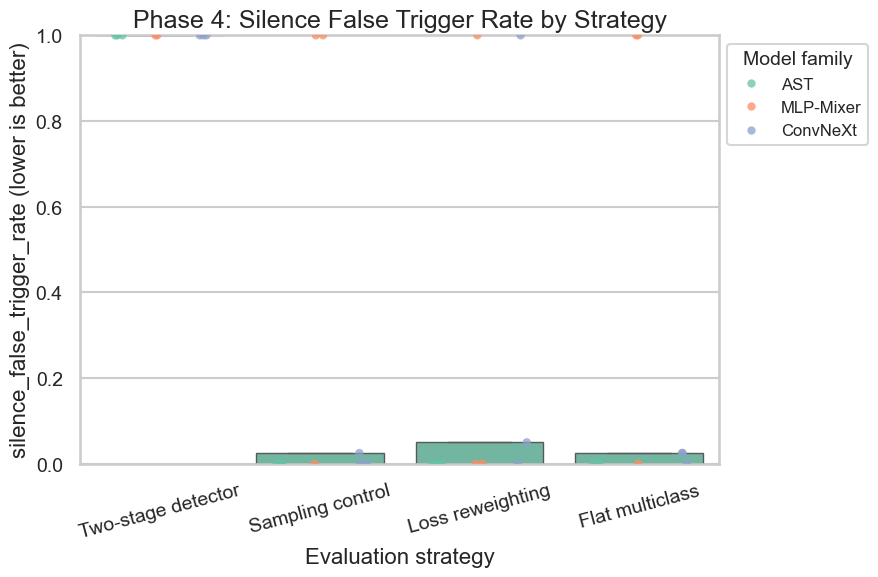

In [32]:
# -------- Silence_false_trigger_rate by strategy --------
fig, ax = plt.subplots(figsize=(9, 6))

sns.boxplot(
    data=phase4,
    x="eval_label",
    y="silence_false_trigger_rate",
    fliersize=0,
    ax=ax,
)

sns.stripplot(
    data=phase4,
    x="eval_label",
    y="silence_false_trigger_rate",
    hue="model_label",
    dodge=True,
    size=6,
    alpha=0.75,
    ax=ax,
)

ax.set_title("Phase 4: Silence False Trigger Rate by Strategy", fontsize=18)
ax.set_xlabel("Evaluation strategy", fontsize=16)
ax.set_ylabel("silence_false_trigger_rate (lower is better)", fontsize=16)
ax.set_ylim(0, 1.0)
ax.tick_params(axis="x", rotation=15, labelsize=14)
ax.tick_params(axis="y", labelsize=14)
ax.legend(
    title="Model family",
    bbox_to_anchor=(1, 1),
    loc="upper left",
    fontsize=12,
    title_fontsize=14,
)

plt.tight_layout()
plt.savefig("./plots/phase_4_silence_false_trigger_rate.png", dpi=500)
plt.show()

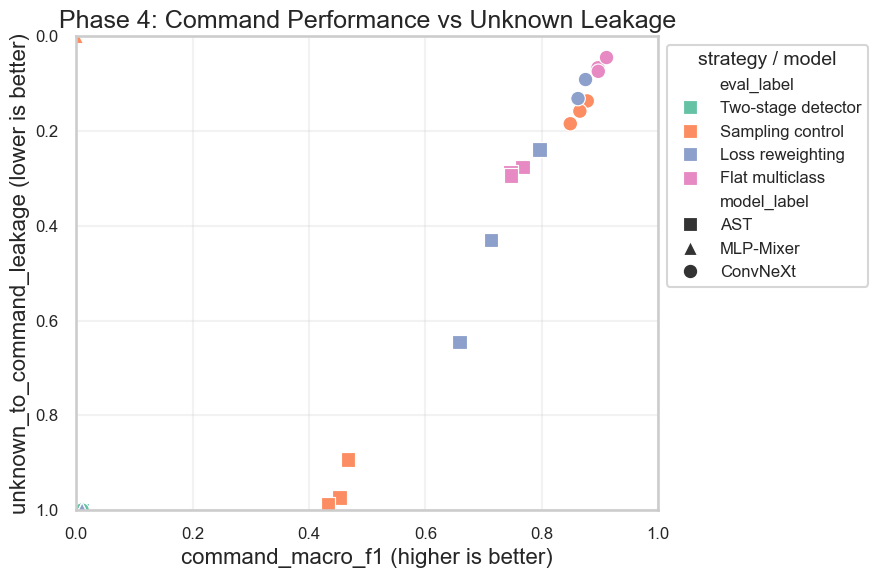

In [33]:
# -------- Scatter --------
fig, ax = plt.subplots(figsize=(9, 6))

markers = {"ConvNeXt": "o", "AST": "s", "MLP-Mixer": "^"}

sns.scatterplot(
    data=phase4,
    x="command_macro_f1",
    y="unknown_to_command_leakage",
    hue="eval_label",
    style="model_label",
    markers=markers,
    s=110,
    ax=ax,
)
ax.set_title("Phase 4: Command Performance vs Unknown Leakage", fontsize=18)
ax.set_xlabel("command_macro_f1 (higher is better)", fontsize=16)
ax.set_ylabel("unknown_to_command_leakage (lower is better)", fontsize=16)
ax.set_xlim(0, 1.0)
ax.set_ylim(0, 1.0)
ax.invert_yaxis()
ax.grid(alpha=0.25)

handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend(
        handles,
        labels,
        title="strategy / model",
        bbox_to_anchor=(1, 1),
        loc="upper left",
        fontsize=12,
        title_fontsize=14,
    )
ax.tick_params(labelsize=12)

plt.tight_layout()
plt.savefig("./plots/phase_4_pareto_scatter.png", dpi=500)
plt.show()

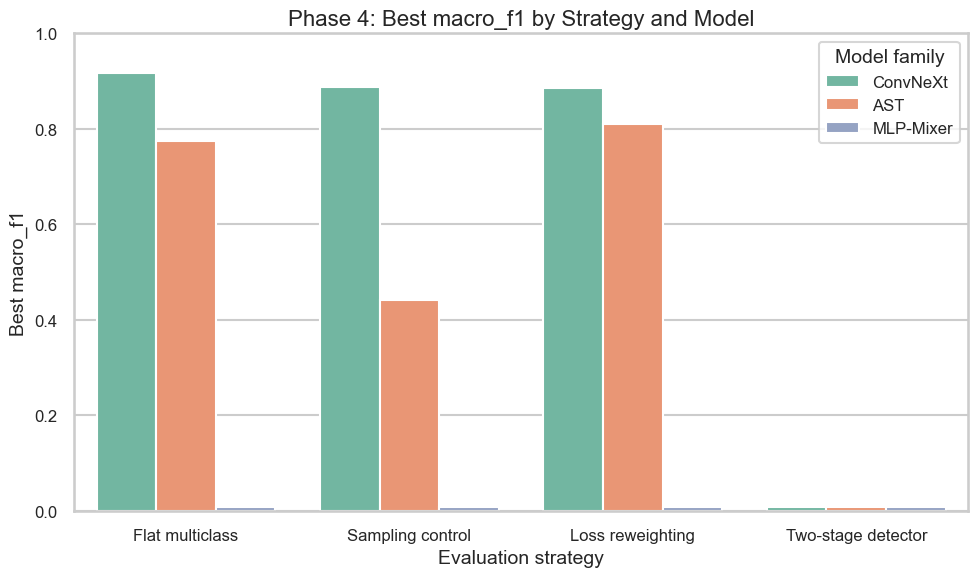

In [34]:
# -------- Plot 3: best macro_f1 by strategy x model --------
best_by_combo = (
    phase4.groupby(["eval_strat", "model_family"], observed=True)["macro_f1"].max().reset_index()
)
best_by_combo["eval_label"] = best_by_combo["eval_strat"].astype(str).map(strategy_display)
best_by_combo["model_label"] = best_by_combo["model_family"].astype(str).map(model_display)

eval_order_labels = [strategy_display[s] for s in strategy_order]
model_order_labels = [model_display[m] for m in model_order]

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=best_by_combo,
    x="eval_label",
    y="macro_f1",
    hue="model_label",
    order=eval_order_labels,
    hue_order=model_order_labels,
    ax=ax,
)

ax.set_title("Phase 4: Best macro_f1 by Strategy and Model", fontsize=16)
ax.set_xlabel("Evaluation strategy", fontsize=14)
ax.set_ylabel("Best macro_f1", fontsize=14)
ax.set_ylim(0, 1.0)
ax.tick_params(labelsize=12)
ax.legend(title="Model family", loc="upper right", fontsize=12, title_fontsize=14)
plt.tight_layout()
# plt.savefig("./plots/phase_4_best_macro_by_strategy_model.png", dpi=500)
plt.show()

# Per-Class Error Analysis (Best Model)

Best run selected for per-class analysis:
run_id                        efd46b1ed29a4a69927bf8d677fdef10
model_family                                          convnext
eval_strat                                     flat_multiclass
trial_seed                                                   0
macro_f1                                              0.917308
command_macro_f1                                      0.911274
unknown_f1                                            0.955199
silence_f1                                            0.939759
unknown_to_command_leakage                            0.044764
silence_false_trigger_rate                                 0.0
Name: 31, dtype: object


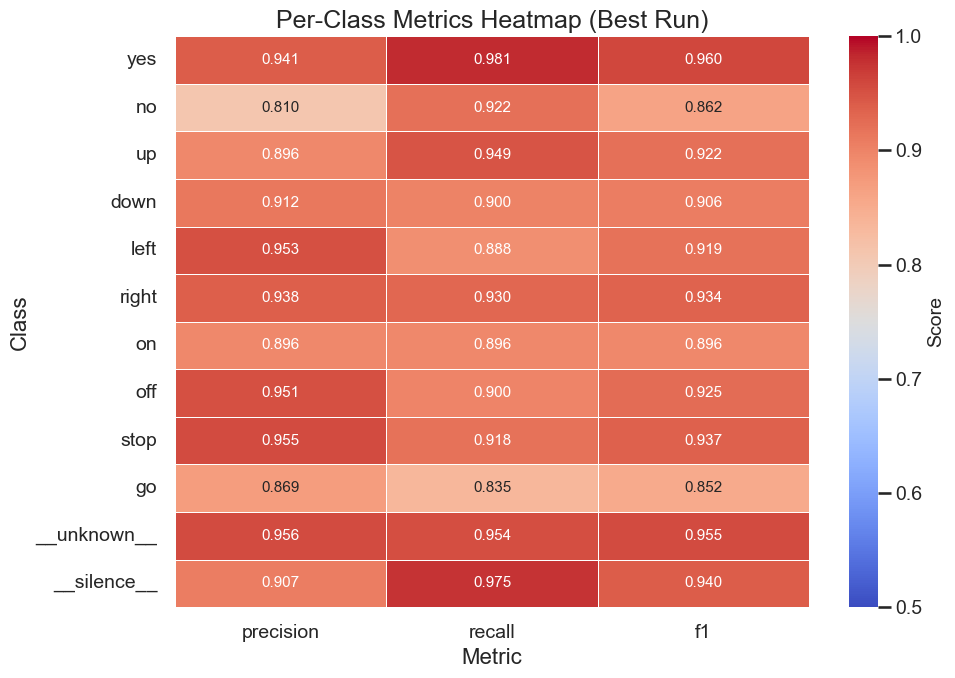

In [35]:
# --- identify top-performing run ---
best_row = phase4.loc[phase4["macro_f1"].idxmax()].copy()
best_run_id = best_row["run_id"]

print("Best run selected for per-class analysis:")
print(
    best_row[
        [
            "run_id",
            "model_family",
            "eval_strat",
            "trial_seed",
            "macro_f1",
            "command_macro_f1",
            "unknown_f1",
            "silence_f1",
            "unknown_to_command_leakage",
            "silence_false_trigger_rate",
        ]
    ]
)

# --- per-class metrics for that run ---
per_class = df_per_class[df_per_class["run_id"] == best_run_id].copy()

# keep a readable class order
class_order = [
    "yes",
    "no",
    "up",
    "down",
    "left",
    "right",
    "on",
    "off",
    "stop",
    "go",
    "__unknown__",
    "__silence__",
]
per_class["class_name"] = pd.Categorical(
    per_class["class_name"], categories=class_order, ordered=True
)
per_class = per_class.sort_values("class_name")

# ---------------- Plot 1: confusion-style heatmap (P/R/F1) ----------------
heat_df = per_class.set_index("class_name")[["precision", "recall", "f1"]]

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    heat_df,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=0.5,
    vmax=1,
    linewidths=0.6,
    cbar_kws={"label": "Score"},
    annot_kws={"size": 11},
    ax=ax,
)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)
cbar.ax.set_ylabel("Score", fontsize=14)

ax.set_title("Per-Class Metrics Heatmap (Best Run)", fontsize=18)
ax.set_xlabel("Metric", fontsize=16)
ax.set_ylabel("Class", fontsize=16)
ax.tick_params(labelsize=14)
plt.tight_layout()
plt.savefig("./plots/per_class_heatmap.png", dpi=500)
plt.show()

# Training Efficiency

/var/folders/j5/3ll6x7154y1gy8h0crlrvl400000gn/T/ipykernel_26807/1528792906.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["run_id", "model_family", "model_label"], as_index=False)


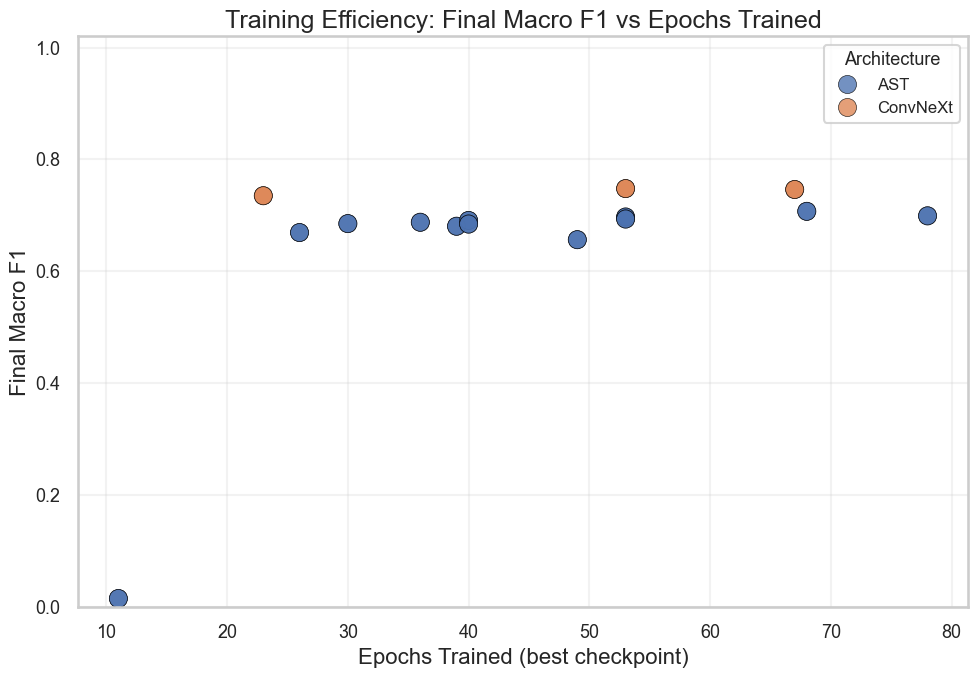

,model_label,runs,mean_epochs,median_epochs,mean_final_f1,max_final_f1
1,ConvNeXt,6,47.666667,53.0,0.743054,0.747840
0,AST,24,43.583333,40.0,0.630555,0.707229


In [36]:
# 8) Training Efficiency
# Scatter: final F1 vs epochs trained (ConvNeXt vs AST)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update(
    {
        "font.size": 14,
        "axes.titlesize": 18,
        "axes.labelsize": 16,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "legend.fontsize": 12,
        "legend.title_fontsize": 13,
    }
)

# Use phase 3 because it is the direct architecture comparison.
# Keep only ConvNeXt and AST as requested.
eff_df = phase3.copy()
eff_df = eff_df[eff_df["model_family"].isin(["convnext", "ast"])].copy()
eff_df = eff_df[["run_id", "model_family", "model_label", "epoch", "macro_f1"]].dropna().copy()

# If multiple rows per run exist, keep the latest checkpoint (max epoch)
eff_df = (
    eff_df.sort_values(["run_id", "epoch"])
    .groupby(["run_id", "model_family", "model_label"], as_index=False)
    .tail(1)
)

eff_df = eff_df.rename(columns={"epoch": "epochs_trained", "macro_f1": "final_macro_f1"})

fig, ax = plt.subplots(figsize=(10, 7))

sns.scatterplot(
    data=eff_df,
    x="epochs_trained",
    y="final_macro_f1",
    hue="model_label",
    # palette="Set2",
    s=170,
    alpha=0.78,
    edgecolor="black",
    linewidth=0.5,
    ax=ax,
)

ax.set_title("Training Efficiency: Final Macro F1 vs Epochs Trained", fontsize=18)
ax.set_xlabel("Epochs Trained (best checkpoint)", fontsize=16)
ax.set_ylabel("Final Macro F1", fontsize=16)
ax.grid(alpha=0.25)
ax.set_ylim(0, 1.02)
ax.legend(title="Architecture", loc="best", frameon=True, fontsize=12)

plt.tight_layout()
plt.savefig("./plots/training_efficiency_scatter.png", dpi=500)
plt.show()

eff_df.groupby("model_label", as_index=False).agg(
    runs=("run_id", "count"),
    mean_epochs=("epochs_trained", "mean"),
    median_epochs=("epochs_trained", "median"),
    mean_final_f1=("final_macro_f1", "mean"),
    max_final_f1=("final_macro_f1", "max"),
).sort_values("mean_final_f1", ascending=False)